In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

In [3]:
PROJECT_ROOT = Path("..")

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
DATA_LATENT = PROJECT_ROOT / "data" / "latent"
DATA_BACKTESTS = PROJECT_ROOT / "data" / "backtests"

returns = pd.read_parquet(DATA_PROCESSED / "returns.parquet")
features = pd.read_parquet(DATA_PROCESSED / "features.parquet")
latent_df = pd.read_parquet(DATA_LATENT / "fc_vae_latents.parquet")

returns.index = pd.to_datetime(returns.index)
features.index = pd.to_datetime(features.index)
latent_df["date"] = pd.to_datetime(latent_df["date"])

DATA_BACKTESTS.mkdir(parents=True, exist_ok=True)

In [4]:
HORIZON = 10
REBALANCE_EVERY = 10
TRAIN_RATIO = 0.7

LONG_Q = 0.8
SHORT_Q = 0.2

TRANSACTION_COST = 0.0

In [5]:
def make_future_returns(returns, horizon):
    future = pd.DataFrame(
        0.0,
        index=returns.index,
        columns=returns.columns
    )

    for h in range(1, horizon + 1):
        future += returns.shift(-h)

    return future

In [6]:
def performance_stats(r):
    r = r.dropna()

    total_return = (1 + r).prod() - 1
    ann_return = (1 + total_return) ** (252 / len(r)) - 1
    ann_vol = r.std() * np.sqrt(252)
    sharpe = ann_return / ann_vol if ann_vol > 0 else np.nan

    equity = (1 + r).cumprod()
    running_max = equity.cummax()
    drawdown = equity / running_max - 1
    max_drawdown = drawdown.min()

    return pd.Series({
        "total_return": total_return,
        "ann_return": ann_return,
        "ann_vol": ann_vol,
        "sharpe": sharpe,
        "max_drawdown": max_drawdown,
    })

In [7]:
def build_rebalanced_positions_from_scores(
    score_df,
    rebalance_every=10,
    long_q=0.8,
    short_q=0.2
):
    dates = score_df.index
    tickers = score_df.columns

    positions = pd.DataFrame(
        0.0,
        index=dates,
        columns=tickers
    )

    current_position = pd.Series(0.0, index=tickers)

    for i, date in enumerate(dates):
        if i % rebalance_every == 0:
            scores = score_df.loc[date].dropna()

            long_threshold = scores.quantile(long_q)
            short_threshold = scores.quantile(short_q)

            new_position = pd.Series(0.0, index=tickers)
            new_position.loc[scores[scores >= long_threshold].index] = 1.0
            new_position.loc[scores[scores <= short_threshold].index] = -1.0

            current_position = new_position

        positions.loc[date] = current_position

    return positions

In [8]:
def portfolio_returns_from_positions(
    positions,
    returns,
    transaction_cost=0.0
):
    next_returns = returns.shift(-1)

    common_index = positions.index.intersection(next_returns.index)
    common_cols = positions.columns.intersection(next_returns.columns)

    pos = positions.loc[common_index, common_cols]
    ret = next_returns.loc[common_index, common_cols]

    gross = (pos * ret).mean(axis=1)

    turnover = pos.diff().abs().mean(axis=1).fillna(0.0)
    costs = transaction_cost * turnover

    net = gross - costs

    return net, turnover

In [9]:
common_dates = np.sort(latent_df["date"].unique())

split_date = common_dates[int(TRAIN_RATIO * len(common_dates))]

split_date

np.datetime64('2022-03-18T00:00:00.000000000')

In [10]:
future_returns = make_future_returns(returns, HORIZON)

z_cols = [c for c in latent_df.columns if c.startswith("z_")]

latent_work = latent_df.copy()

target_values = []

for _, row in latent_work[["date", "ticker"]].iterrows():
    date = row["date"]
    ticker = row["ticker"]

    try:
        target_values.append(future_returns.loc[date, ticker])
    except KeyError:
        target_values.append(np.nan)

latent_work["target_return"] = target_values
latent_work = latent_work.dropna(subset=["target_return"]).copy()

In [11]:
train_mask = latent_work["date"] < split_date
test_mask = latent_work["date"] >= split_date

X_train = latent_work.loc[train_mask, z_cols].values
y_train = latent_work.loc[train_mask, "target_return"].values

X_test = latent_work.loc[test_mask, z_cols].values
y_test = latent_work.loc[test_mask, "target_return"].values

latent_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=10.0))
])

latent_model.fit(X_train, y_train)

latent_train_pred = latent_model.predict(X_train)
latent_test_pred = latent_model.predict(X_test)

print("Latent train corr:", np.corrcoef(y_train, latent_train_pred)[0, 1])
print("Latent test corr:", np.corrcoef(y_test, latent_test_pred)[0, 1])
print("Latent test MSE:", mean_squared_error(y_test, latent_test_pred))

Latent train corr: 0.13792668658494373
Latent test corr: 0.042335793181815386
Latent test MSE: 0.004440237161676287


/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/v

In [12]:
latent_work["score"] = latent_model.predict(latent_work[z_cols].values)

latent_score_df = latent_work.pivot(
    index="date",
    columns="ticker",
    values="score"
).sort_index()

latent_score_test = latent_score_df.loc[latent_score_df.index >= split_date]

/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


In [13]:
latent_positions = build_rebalanced_positions_from_scores(
    latent_score_test,
    rebalance_every=REBALANCE_EVERY,
    long_q=LONG_Q,
    short_q=SHORT_Q
)

latent_returns, latent_turnover = portfolio_returns_from_positions(
    latent_positions,
    returns,
    transaction_cost=TRANSACTION_COST
)

latent_returns.name = "latent_ridge"

In [14]:
feature_names = features.columns.get_level_values("feature").unique().tolist()
tickers = features.columns.get_level_values("ticker").unique().tolist()

raw_rows = []

for ticker in tickers:
    df_t = features[ticker].copy()
    df_t["target_return"] = future_returns[ticker]
    df_t["date"] = df_t.index
    df_t["ticker"] = ticker
    raw_rows.append(df_t)

raw_work = pd.concat(raw_rows, axis=0).dropna().copy()

raw_work.head()

feature,momentum_120,momentum_20,momentum_60,return_1d,volatility_20,volatility_60,target_return,date,ticker
Date,,,,,,,,,
2015-06-25,0.175687,-0.032478,0.028952,-0.004762,0.006550,0.011349,-0.032531,2015-06-25,AAPL
2015-06-26,0.202652,-0.027096,0.024382,-0.005882,0.006226,0.011376,-0.007343,2015-06-26,AAPL
2015-06-29,0.181477,-0.046039,-0.002153,-0.017515,0.007136,0.011558,0.009773,2015-06-29,AAPL
2015-06-30,0.173559,-0.034857,-0.010962,0.007227,0.007425,0.011402,0.012180,2015-06-30,AAPL
2015-07-01,0.140679,-0.027052,0.008879,0.009328,0.007807,0.011383,0.016177,2015-07-01,AAPL


In [15]:
raw_train_mask = raw_work["date"] < split_date
raw_test_mask = raw_work["date"] >= split_date

X_train_raw = raw_work.loc[raw_train_mask, feature_names].values
y_train_raw = raw_work.loc[raw_train_mask, "target_return"].values

X_test_raw = raw_work.loc[raw_test_mask, feature_names].values
y_test_raw = raw_work.loc[raw_test_mask, "target_return"].values

raw_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=10.0))
])

raw_model.fit(X_train_raw, y_train_raw)

raw_train_pred = raw_model.predict(X_train_raw)
raw_test_pred = raw_model.predict(X_test_raw)

print("Raw train corr:", np.corrcoef(y_train_raw, raw_train_pred)[0, 1])
print("Raw test corr:", np.corrcoef(y_test_raw, raw_test_pred)[0, 1])
print("Raw test MSE:", mean_squared_error(y_test_raw, raw_test_pred))

Raw train corr: 0.15299767267275444
Raw test corr: 0.030358374412970825
Raw test MSE: 0.0044625342781618865


/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/v

In [16]:
raw_work["score"] = raw_model.predict(raw_work[feature_names].values)

raw_score_df = raw_work.pivot(
    index="date",
    columns="ticker",
    values="score"
).sort_index()

raw_score_test = raw_score_df.loc[raw_score_df.index >= split_date]

/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


In [17]:
raw_positions = build_rebalanced_positions_from_scores(
    raw_score_test,
    rebalance_every=REBALANCE_EVERY,
    long_q=LONG_Q,
    short_q=SHORT_Q
)

raw_returns, raw_turnover = portfolio_returns_from_positions(
    raw_positions,
    returns,
    transaction_cost=TRANSACTION_COST
)

raw_returns.name = "raw_feature_ridge"

In [18]:
comparison_returns = pd.concat(
    [latent_returns, raw_returns],
    axis=1
).dropna()

comparison_returns.head()

,latent_ridge,raw_feature_ridge
2022-03-18,-0.001509,0.000692
2022-03-21,0.003824,0.004241
2022-03-22,-0.002625,-0.001548
2022-03-23,0.006762,0.005071
2022-03-24,-0.002514,-0.001398


In [19]:
stats = comparison_returns.apply(performance_stats).T

stats

,total_return,ann_return,ann_vol,sharpe,max_drawdown
latent_ridge,0.103629,0.036614,0.064182,0.570474,-0.115144
raw_feature_ridge,0.170609,0.059129,0.068879,0.858448,-0.078861


In [20]:
turnover_stats = pd.Series({
    "latent_avg_turnover": latent_turnover.mean(),
    "raw_avg_turnover": raw_turnover.mean(),
})

turnover_stats

latent_avg_turnover    0.019006
raw_avg_turnover       0.022672
dtype: float64

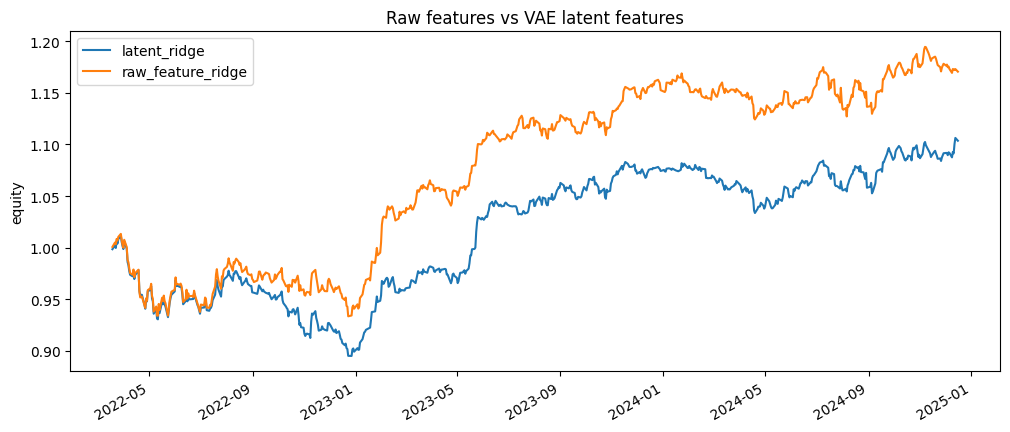

In [21]:
equity = (1 + comparison_returns).cumprod()

equity.plot(
    figsize=(12, 5),
    title="Raw features vs VAE latent features"
)

plt.ylabel("equity")
plt.show()

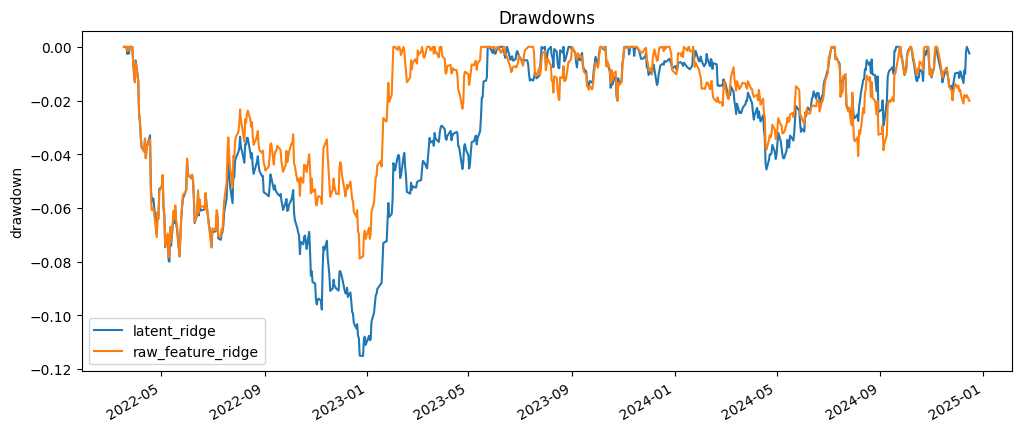

In [22]:
drawdowns = equity / equity.cummax() - 1

drawdowns.plot(
    figsize=(12, 5),
    title="Drawdowns"
)

plt.ylabel("drawdown")
plt.show()

In [23]:
comparison_returns.to_parquet(
    DATA_BACKTESTS / "raw_vs_latent_returns.parquet"
)

stats.to_csv(
    DATA_BACKTESTS / "raw_vs_latent_stats.csv"
)

In [24]:
stats
turnover_stats

latent_avg_turnover    0.019006
raw_avg_turnover       0.022672
dtype: float64

In [26]:
turnover_stats

latent_avg_turnover    0.019006
raw_avg_turnover       0.022672
dtype: float64

In [25]:
stats

,total_return,ann_return,ann_vol,sharpe,max_drawdown
latent_ridge,0.103629,0.036614,0.064182,0.570474,-0.115144
raw_feature_ridge,0.170609,0.059129,0.068879,0.858448,-0.078861
